Step 1 Import Libraries

In [91]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

Step 2 Load Dataset

In [92]:
df = pd.read_csv("/content/dataset_Facebook.csv", sep=';')

print(df.shape)

print(df.info())

print(df.describe())

print(df.head())

(500, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7 

Step 3 Check Missing Values

In [93]:
print(df.isnull().sum())


Page total likes                                                       0
Type                                                                   0
Category                                                               0
Post Month                                                             0
Post Weekday                                                           0
Post Hour                                                              0
Paid                                                                   1
Lifetime Post Total Reach                                              0
Lifetime Post Total Impressions                                        0
Lifetime Engaged Users                                                 0
Lifetime Post Consumers                                                0
Lifetime Post Consumptions                                             0
Lifetime Post Impressions by people who have liked your Page           0
Lifetime Post reach by people who like your Page   

Step 4 Handle Missing Values

In [94]:
# Paid -> Mode
df["Paid"].fillna(df["Paid"].mode()[0], inplace=True)

# like -> Median
df["like"].fillna(df["like"].median(), inplace=True)

# share -> Median
df["share"].fillna(df["share"].median(), inplace=True)

/tmp/ipykernel_2465/3468642606.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Paid"].fillna(df["Paid"].mode()[0], inplace=True)
/tmp/ipykernel_2465/3468642606.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

Step 5 Remove Duplicates

In [95]:
df = df.drop_duplicates()

print(df.shape)

(500, 19)


Step 6 Detect & Cap Outliers (IQR Method)

Use two numeric columns.

In [96]:
def cap_outliers(col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

cap_outliers("like")
cap_outliers("share")

Step 7 Load into SQLite

In [97]:
conn = sqlite3.connect("facebook.db")

df.to_sql("facebook_posts", conn,
          if_exists="replace",
          index=False)

500

In [98]:
connection = sqlite3.connect('facebook.db')

In [99]:
cursor = connection.cursor()

In [100]:
!pip install ipython-sql

In [101]:
# load extension

%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [102]:
# to connect created database

%sql sqlite:///facebook.db

Step 8 SQL Queries (queries.sql)


In [103]:
sql = """
SELECT * FROM facebook_posts;

SELECT Type, COUNT(*)
FROM facebook_posts
GROUP BY Type;

# Query 1 (WHERE)

SELECT *
FROM facebook_posts
WHERE "Total Interactions" > 500;

# Query 2 (GROUP BY)

SELECT Type,
AVG("Total Interactions") AS AvgInteractions
FROM facebook_posts
GROUP BY Type;


result = pd.read_sql_query(query, conn)
print(result)

# Query 3 (HAVING)

SELECT Type,
COUNT(*) AS TotalPosts
FROM facebook_posts
GROUP BY Type
HAVING COUNT(*) > 20;

result = pd.read_sql_query(query, conn)
print(result)

# Query 4 (ORDER BY + LIMIT)

SELECT *
FROM facebook_posts
ORDER BY like DESC
LIMIT 10;

result = pd.read_sql_query(query, conn)
print(result)

# Query 5 (BETWEEN)

SELECT *
FROM facebook_posts
WHERE "Post Month"
BETWEEN 6 AND 12;

result = pd.read_sql_query(query, conn)
print(result)

# Query 6 (AND condition)

SELECT *
FROM facebook_posts
WHERE Type='Photo'
AND "Total Interactions" > 500;

result = pd.read_sql_query(query, conn)
print(result)


"""

result = pd.read_sql_query(query, conn)
print(result)


with open("queries.sql", "w") as file:
    file.write(sql)

print("queries.sql created successfully!")

    Page total likes    Type  Category  Post Month  Post Weekday  Post Hour  \
0             139441   Photo         2          12             2         10   
1             138414   Photo         2          12             4          5   
2             138414   Photo         1          12             2         12   
3             138895   Photo         2          12             5          3   
4             138185   Photo         1          11             7          3   
5             137893   Video         1          11             5          3   
6             137893   Photo         1          11             3          2   
7             137020   Photo         2          10             4          3   
8             137020   Photo         1          10             2          4   
9             136013  Status         2          10             3          2   
10            135428   Photo         3           9             4          2   
11            135428   Photo         1           9  

In [104]:
from google.colab import files
files.download("queries.sql")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 9 Visualizations

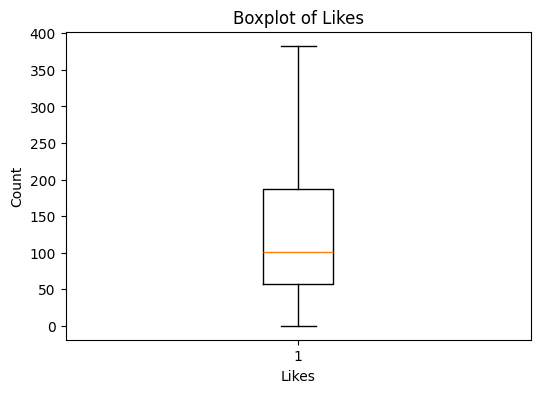

In [105]:
# 1 Boxplot

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["like"])
plt.title("Boxplot of Likes")
plt.xlabel("Likes")
plt.ylabel("Count")
plt.show()


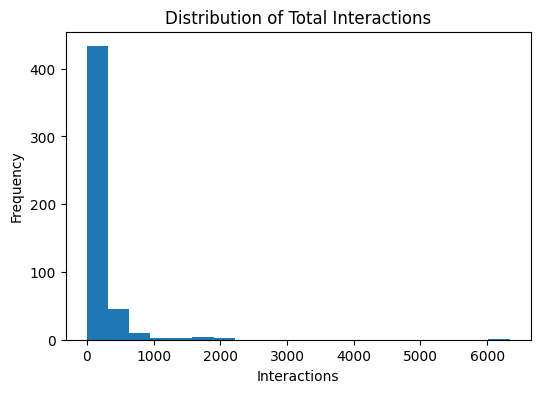

In [106]:
# 2 Histogram
plt.figure(figsize=(6,4))

plt.hist(df["Total Interactions"], bins=20)

plt.title("Distribution of Total Interactions")

plt.xlabel("Interactions")

plt.ylabel("Frequency")

plt.show()

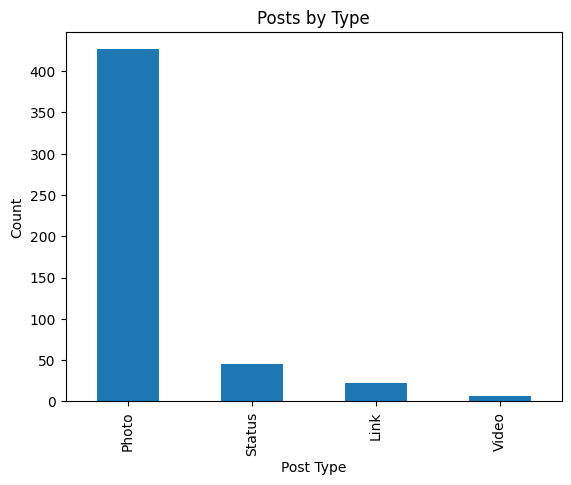

In [107]:
# 3 Bar Chart

df["Type"].value_counts().plot(kind="bar")

plt.title("Posts by Type")

plt.xlabel("Post Type")

plt.ylabel("Count")

plt.show()

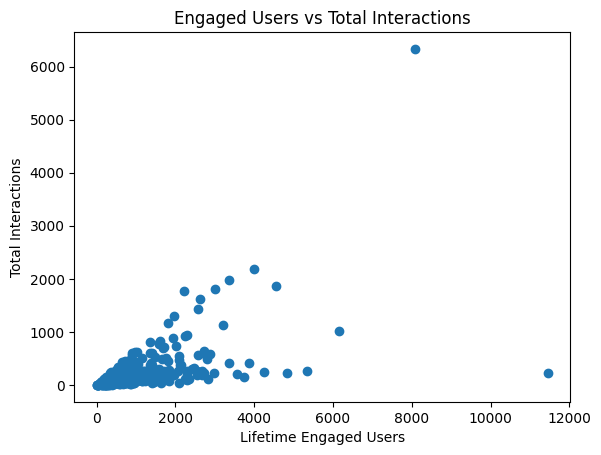

In [108]:
# 4 Scatter Plot
plt.scatter(df["Lifetime Engaged Users"],
            df["Total Interactions"])

plt.title("Engaged Users vs Total Interactions")

plt.xlabel("Lifetime Engaged Users")

plt.ylabel("Total Interactions")

plt.show()

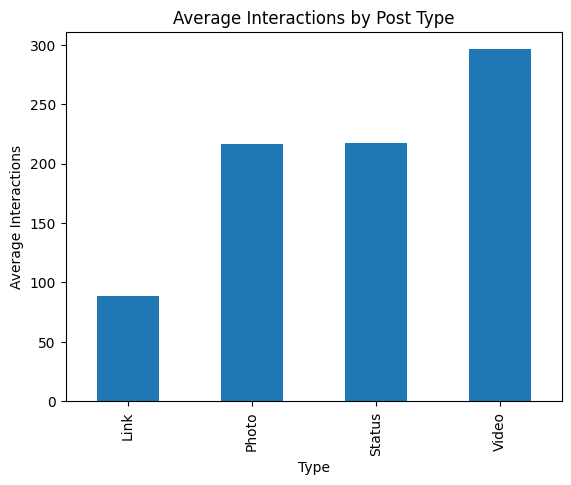

In [109]:
# 5 GroupBy Chart

df.groupby("Type")["Total Interactions"].mean().plot(kind="bar")

plt.title("Average Interactions by Post Type")

plt.xlabel("Type")

plt.ylabel("Average Interactions")

plt.show()

Requirements

In [110]:
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
sqlalchemy
pymysql
google colab
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

!cat requirements.txt

from google.colab import files
files.download("requirements.txt")


requirements.txt created successfully!
pandas
numpy
matplotlib
seaborn
scikit-learn
sqlalchemy
pymysql
google colab


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>